## Spectral pretreatment pipeline

The spectral preprocessing was applied in the following order:

1. Moving average smoothing to reduce white noise  
2. Standard Normal Variate (SNV) normalization to correct multiplicative effects  
3. Savitzky-Golay first derivative to correct baseline drift and improve peak resolution  
4. Principal Component Analysis (PCA) for dimensionality reduction

In [12]:

#Import necessary libraries
!pip install matplotlib
!pip install pandas
!pip install seaborn
!pip install numpy
!pip install statsmodels
!pip install scikit-learn
!pip install torch
!pip install scipy
!pip install chemotools 

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from chemotools.derivative import SavitzkyGolay
from chemotools.scatter import StandardNormalVariate
from chemotools.feature_selection import RangeCut
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA 
from sklearn.cross_decomposition import PLSRegression
from scipy.signal import savgol_filter

## 1. Load the dataset

We first load the combined dataset, then separate the spectral variables from the target labels.

In [3]:
combined_data = pd.read_csv("combined_data.csv")

spectra = combined_data.drop(columns="class")
labels = combined_data["class"]

print("Dimensions du dataset complet :", combined_data.shape)
print("Dimensions des spectres :", spectra.shape)
print("\nAperçu des classes :")
print(labels.head())

display(combined_data.head())

Dimensions du dataset complet : (160, 225)
Dimensions des spectres : (160, 224)

Aperçu des classes :
0    canola
1    canola
2    canola
3    canola
4    canola
Name: class, dtype: str


,397.66,400.28,402.9,405.52,408.13,410.75,413.37,416.0,418.62,421.24,...,981.27,984.09,986.9,989.72,992.54,995.35,998.17,1000.99,1003.81,class
0,0.160989,0.152837,0.143099,0.132230,0.121732,0.113088,0.106684,0.102206,0.097464,0.094226,...,0.268508,0.268674,0.268942,0.269235,0.269651,0.270141,0.270695,0.271260,0.271902,canola
1,0.157316,0.148315,0.139275,0.129330,0.120090,0.112003,0.105155,0.100885,0.097040,0.093725,...,0.277404,0.277630,0.277895,0.278252,0.278681,0.279293,0.279852,0.280512,0.281131,canola
2,0.180705,0.171157,0.159826,0.147212,0.136382,0.126773,0.119723,0.115086,0.109832,0.105594,...,0.304266,0.304477,0.304762,0.305169,0.305732,0.306397,0.307044,0.307668,0.308387,canola
3,0.159618,0.151638,0.141948,0.131743,0.121592,0.112819,0.106271,0.101794,0.097496,0.094452,...,0.270041,0.270336,0.270555,0.270984,0.271544,0.272093,0.272727,0.273407,0.274073,canola
4,0.147031,0.139998,0.130906,0.121395,0.112400,0.104592,0.098618,0.095303,0.091420,0.088122,...,0.247827,0.248123,0.248419,0.248833,0.249397,0.249951,0.250570,0.251253,0.251939,canola


## 2. Explore the dataset

We check the number of samples, the number of wavelengths, and the class distribution.

The spectra dataset has 160 samples
The spectra dataset has 224 features


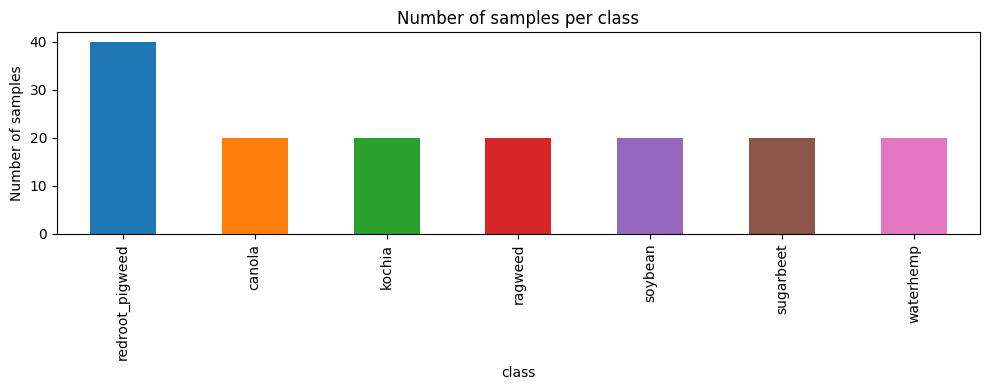

In [4]:
print(f"The spectra dataset has {spectra.shape[0]} samples")
print(f"The spectra dataset has {spectra.shape[1]} features")

counts = labels.value_counts()
colors = plt.cm.tab10(range(len(counts)))

fig, ax = plt.subplots(figsize=(10, 4))
counts.plot.bar(color=colors, ax=ax)
ax.set_ylabel("Number of samples")
ax.set_title("Number of samples per class")
plt.tight_layout()
plt.show()

## 3. Define the class colors

We assign one color to each plant class in order to keep the same color code throughout the notebook.

In [5]:
color_dict = {
    "redroot_pigweed": "red",
    "canola": "salmon",
    "kochia": "lightgreen",
    "ragweed": "green",
    "soybean": "yellow",
    "sugarbeet": "lightblue",
    "waterhemp": "blue"
}

label_colors = labels.map(color_dict)

print(labels.iloc[0], "->", label_colors.iloc[0])

missing_classes = set(labels.unique()) - set(color_dict.keys())
if missing_classes:
    print("Warning: missing colors for these classes:", missing_classes)

canola -> salmon


## 4. Plot the raw spectra

Each spectrum is plotted as a function of wavelength.  
The color indicates the class of the sample.

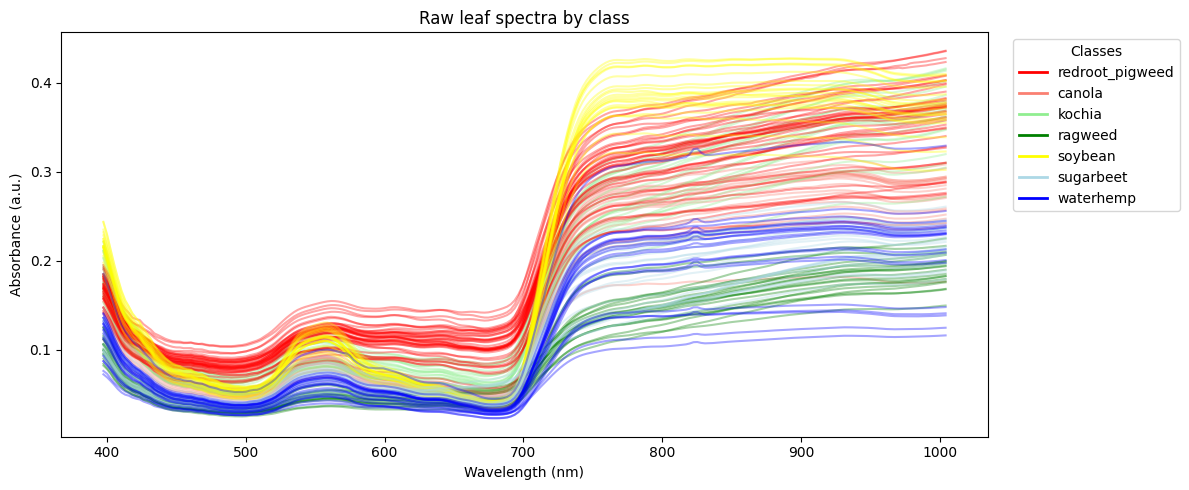

In [6]:
wavelengths = spectra.columns.astype(float)

legend_handles = [
    plt.Line2D([0], [0], color=color, lw=2, label=label)
    for label, color in color_dict.items()
]

fig, ax = plt.subplots(figsize=(12, 5))

for i, (_, row) in enumerate(spectra.iterrows()):
    ax.plot(wavelengths, row.values, color=color_dict[labels.iloc[i]], alpha=0.35)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Absorbance (a.u.)")
ax.set_title("Raw leaf spectra by class")
ax.legend(handles=legend_handles, title="Classes", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 5. Step 1: SNV normalization

SNV (Standard Normal Variate) is applied spectrum by spectrum.  
For each sample, we subtract the mean and divide by the standard deviation.

In [16]:
spectra_snv = spectra.apply(lambda row: (row - row.mean()) / row.std(), axis=1)

print("Shape after SNV:", spectra_snv.shape)
display(spectra_snv.head())

Shape after SNV: (160, 224)


,397.66,400.28,402.9,405.52,408.13,410.75,413.37,416.0,418.62,421.24,...,978.46,981.27,984.09,986.9,989.72,992.54,995.35,998.17,1000.99,1003.81
0,0.021991,-0.059972,-0.157871,-0.267147,-0.372690,-0.459593,-0.523975,-0.569004,-0.616671,-0.649223,...,1.103340,1.102957,1.104627,1.107320,1.110264,1.114446,1.119375,1.124946,1.130622,1.137080
1,-0.056537,-0.146615,-0.237072,-0.336589,-0.429059,-0.509979,-0.578510,-0.621239,-0.659716,-0.692888,...,1.143960,1.145175,1.147432,1.150092,1.153656,1.157948,1.164074,1.169676,1.176271,1.182473
2,0.014882,-0.071325,-0.173628,-0.287522,-0.385305,-0.472069,-0.535723,-0.577586,-0.625030,-0.663298,...,1.128758,1.130516,1.132421,1.134998,1.138675,1.143750,1.149760,1.155596,1.161234,1.167727
3,0.019640,-0.064373,-0.166396,-0.273828,-0.380698,-0.473058,-0.541999,-0.589138,-0.634385,-0.666431,...,1.180043,1.182173,1.185280,1.187587,1.192104,1.197996,1.203780,1.210451,1.217612,1.224616
4,0.033743,-0.047518,-0.152561,-0.262453,-0.366377,-0.456585,-0.525604,-0.563909,-0.608774,-0.646873,...,1.196020,1.198303,1.201722,1.205140,1.209926,1.216435,1.222836,1.229991,1.237885,1.245806


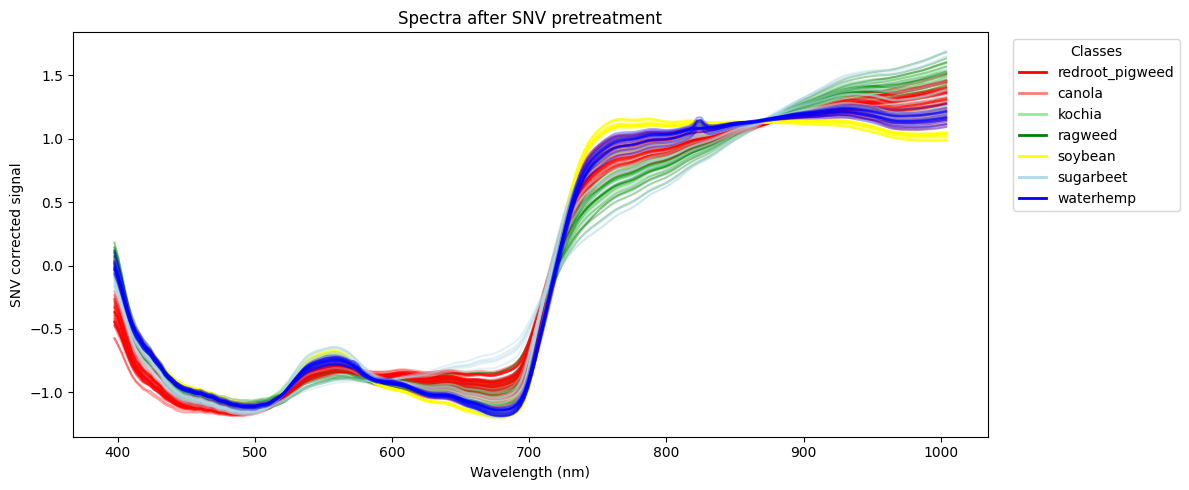

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, (_, row) in enumerate(spectra_snv.iterrows()):
    ax.plot(wavelengths, row.values, color=color_dict[labels.iloc[i]], alpha=0.35)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("SNV corrected signal")
ax.set_title("Spectra after SNV pretreatment")
ax.legend(handles=legend_handles, title="Classes", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 6. Step 2: Savitzky-Golay first derivative

The Savitzky-Golay first derivative is used to correct baseline drift and improve peak resolution.

In [88]:
window_length = 17
polyorder = 3
deriv_order = 1

spectra_sg = pd.DataFrame(
    savgol_filter(
        spectra_snv.values,
        window_length=window_length,
        polyorder=polyorder,
        deriv=deriv_order,
        axis=1
    ),
    index=spectra_snv.index,
    columns=spectra_snv.columns
)

print("Shape after Savitzky-Golay derivative:", spectra_sg.shape)
display(spectra_sg.head())

Shape after Savitzky-Golay derivative: (160, 224)


,397.66,400.28,402.9,405.52,408.13,410.75,413.37,416.0,418.62,421.24,...,978.46,981.27,984.09,986.9,989.72,992.54,995.35,998.17,1000.99,1003.81
0,-0.132850,-0.117417,-0.103281,-0.090442,-0.078901,-0.068656,-0.059708,-0.052058,-0.045704,-0.038985,...,0.000065,0.000992,0.001957,0.002843,0.003652,0.004384,0.005037,0.005613,0.006111,0.006532
1,-0.124919,-0.110422,-0.097140,-0.085072,-0.074218,-0.064578,-0.056153,-0.048942,-0.042946,-0.037131,...,0.000772,0.001707,0.002652,0.003502,0.004258,0.004920,0.005488,0.005962,0.006341,0.006626
2,-0.134575,-0.118624,-0.104045,-0.090839,-0.079006,-0.068546,-0.059459,-0.051745,-0.045404,-0.039352,...,0.001500,0.002329,0.003205,0.003958,0.004589,0.005096,0.005480,0.005742,0.005880,0.005895
3,-0.136362,-0.120470,-0.105904,-0.092665,-0.080751,-0.070163,-0.060902,-0.052966,-0.046356,-0.039334,...,0.002077,0.002912,0.003789,0.004545,0.005180,0.005695,0.006089,0.006363,0.006516,0.006549
4,-0.134683,-0.119060,-0.104766,-0.091800,-0.080163,-0.069855,-0.060875,-0.053225,-0.046903,-0.040433,...,0.002272,0.003103,0.004005,0.004820,0.005549,0.006191,0.006747,0.007216,0.007599,0.007895


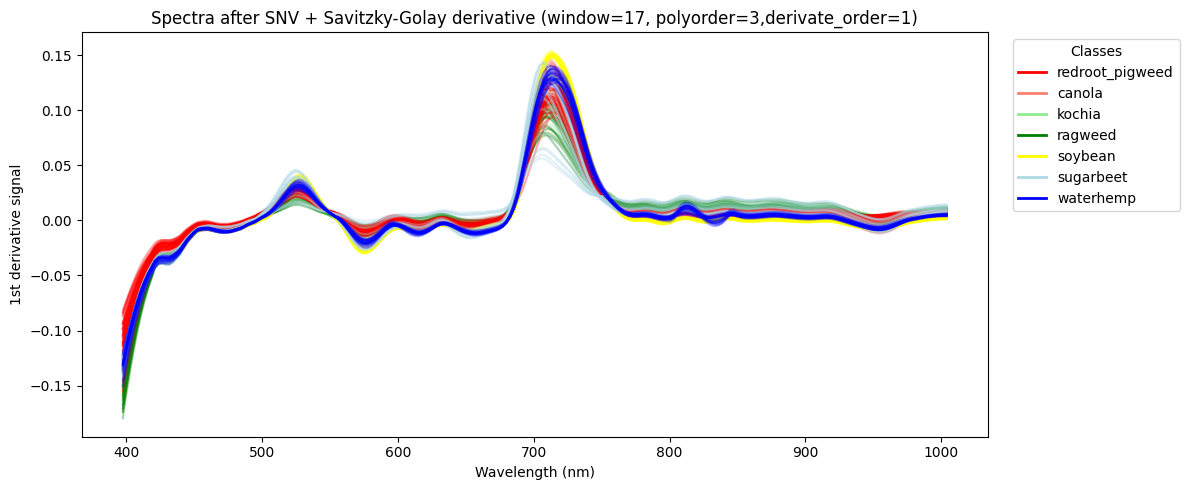

In [89]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, (_, row) in enumerate(spectra_sg.iterrows()):
    ax.plot(wavelengths, row.values, color=color_dict[labels.iloc[i]], alpha=0.35)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("1st derivative signal")
ax.set_title(f"Spectra after SNV + Savitzky-Golay derivative (window={window_length}, polyorder={polyorder},derivate_order={deriv_order})")
ax.legend(handles=legend_handles, title="Classes", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 7. Compare one spectrum before and after preprocessing

To better visualize the effect of each preprocessing step, we compare one sample through the entire pipeline.

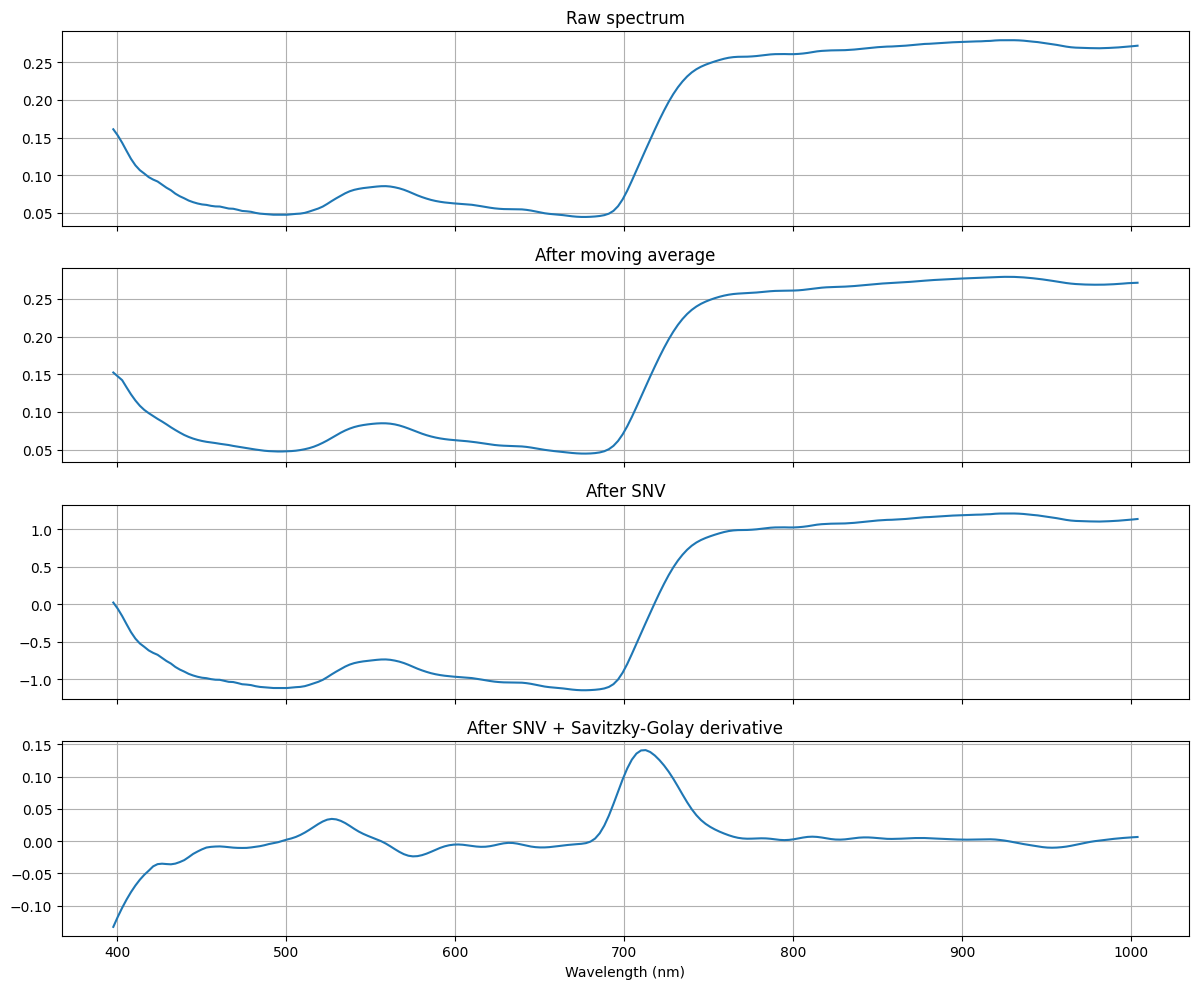

In [90]:
sample_idx = 0

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(wavelengths, spectra.iloc[sample_idx].values)
axes[0].set_title("Raw spectrum")

axes[1].plot(wavelengths, spectra_ma.iloc[sample_idx].values)
axes[1].set_title("After moving average")

axes[2].plot(wavelengths, spectra_snv.iloc[sample_idx].values)
axes[2].set_title("After SNV")

axes[3].plot(wavelengths, spectra_sg.iloc[sample_idx].values)
axes[3].set_title("After SNV + Savitzky-Golay derivative")

for ax in axes:
    ax.grid(True)

axes[-1].set_xlabel("Wavelength (nm)")
plt.tight_layout()
plt.show()

## 8. Final preprocessed dataset

The final preprocessed spectra correspond to the spectra after  SNV normalization, and Savitzky-Golay derivative.

In [91]:
preprocessed_spectra = spectra_sg.copy()

print("Final preprocessed dataset shape:", preprocessed_spectra.shape)
display(preprocessed_spectra.head())

Final preprocessed dataset shape: (160, 224)


,397.66,400.28,402.9,405.52,408.13,410.75,413.37,416.0,418.62,421.24,...,978.46,981.27,984.09,986.9,989.72,992.54,995.35,998.17,1000.99,1003.81
0,-0.132850,-0.117417,-0.103281,-0.090442,-0.078901,-0.068656,-0.059708,-0.052058,-0.045704,-0.038985,...,0.000065,0.000992,0.001957,0.002843,0.003652,0.004384,0.005037,0.005613,0.006111,0.006532
1,-0.124919,-0.110422,-0.097140,-0.085072,-0.074218,-0.064578,-0.056153,-0.048942,-0.042946,-0.037131,...,0.000772,0.001707,0.002652,0.003502,0.004258,0.004920,0.005488,0.005962,0.006341,0.006626
2,-0.134575,-0.118624,-0.104045,-0.090839,-0.079006,-0.068546,-0.059459,-0.051745,-0.045404,-0.039352,...,0.001500,0.002329,0.003205,0.003958,0.004589,0.005096,0.005480,0.005742,0.005880,0.005895
3,-0.136362,-0.120470,-0.105904,-0.092665,-0.080751,-0.070163,-0.060902,-0.052966,-0.046356,-0.039334,...,0.002077,0.002912,0.003789,0.004545,0.005180,0.005695,0.006089,0.006363,0.006516,0.006549
4,-0.134683,-0.119060,-0.104766,-0.091800,-0.080163,-0.069855,-0.060875,-0.053225,-0.046903,-0.040433,...,0.002272,0.003103,0.004005,0.004820,0.005549,0.006191,0.006747,0.007216,0.007599,0.007895


## 9. PCA on the preprocessed spectra

Because spectral variables are highly correlated, PCA is applied to summarize the information into a smaller number of principal components.

In [95]:
spectra_scaled = StandardScaler(with_std=False).fit_transform(preprocessed_spectra)

pca = PCA(n_components=4)
spectra_pca = pca.fit_transform(spectra_scaled)

spectra_pca_df = pd.DataFrame(
    data=spectra_pca,
    columns=["PC1", "PC2", "PC3", "PC4"],
    index=preprocessed_spectra.index
)

spectra_pca_df["class"] = labels.values

display(spectra_pca_df.head())

,PC1,PC2,PC3,PC4,class
0,0.077968,-0.016550,0.008914,-0.002501,canola
1,0.056379,-0.002204,0.017172,-0.000129,canola
2,0.065266,-0.017090,0.004755,-0.002785,canola
3,0.037937,-0.020667,0.000388,-0.002846,canola
4,0.031844,-0.022998,0.007269,0.000698,canola


## 10. Explained variance

We now examine how much variance is explained by each principal component.

In [96]:
explained_var = pca.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)

print("Explained variance per component (%):")
print(np.round(explained_var, 2))

print("\nCumulative explained variance (%):")
print(np.round(cumulative_var, 2))

print(f"\nTotal variance explained by 4 components: {cumulative_var[-1]:.2f}%")

Explained variance per component (%):
[72.04 16.19  7.83  1.36]

Cumulative explained variance (%):
[72.04 88.23 96.05 97.41]

Total variance explained by 4 components: 97.41%


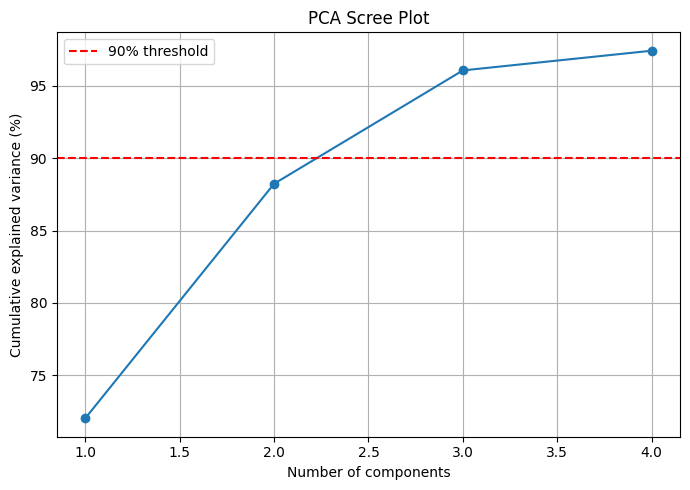

In [97]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker="o")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.axhline(y=90, color="r", linestyle="--", label="90% threshold")
plt.legend()
plt.tight_layout()
plt.show()

## 11. PCA score plot: PC1 vs PC2

This plot shows the distribution of the samples in the space defined by the first two principal components.

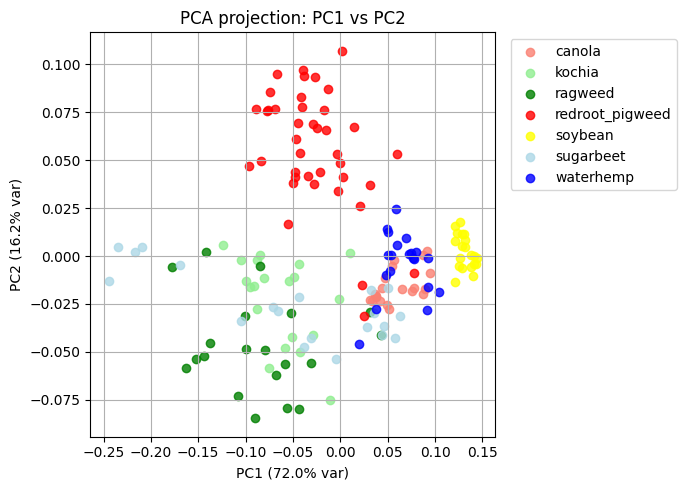

In [98]:
fig, ax = plt.subplots(figsize=(7, 5))

for cls in labels.unique():
    subset = spectra_pca_df[spectra_pca_df["class"] == cls]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=cls,
        color=color_dict[cls],
        alpha=0.8
    )

ax.set_xlabel(f"PC1 ({explained_var[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained_var[1]:.1f}% var)")
ax.set_title("PCA projection: PC1 vs PC2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True)

plt.tight_layout()
plt.show()

## 12. PCA score plot: PC2 vs PC3

This second score plot may reveal separations not visible on PC1 vs PC2.

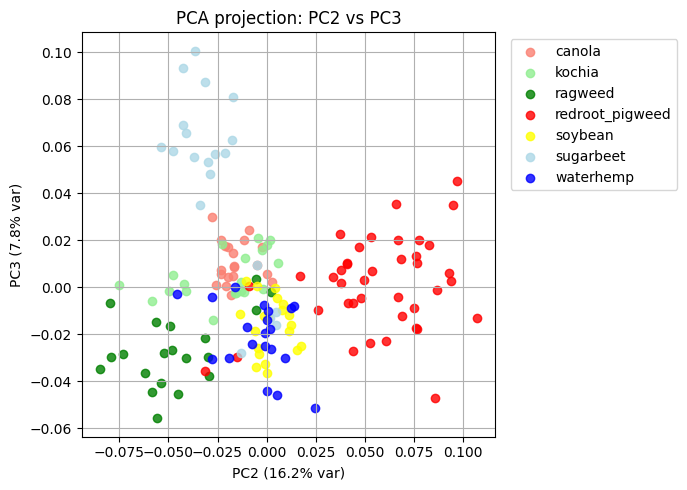

In [101]:
fig, ax = plt.subplots(figsize=(7, 5))

for cls in labels.unique():
    subset = spectra_pca_df[spectra_pca_df["class"] == cls]
    ax.scatter(
        subset["PC2"],
        subset["PC3"],
        label=cls,
        color=color_dict[cls],
        alpha=0.8
    )

ax.set_xlabel(f"PC2 ({explained_var[1]:.1f}% var)")
ax.set_ylabel(f"PC3 ({explained_var[2]:.1f}% var)")
ax.set_title("PCA projection: PC2 vs PC3")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True)

plt.tight_layout()
plt.show()

## 13. PCA score plot: PC3 vs PC4

This plot explores the information contained in the higher-order components.

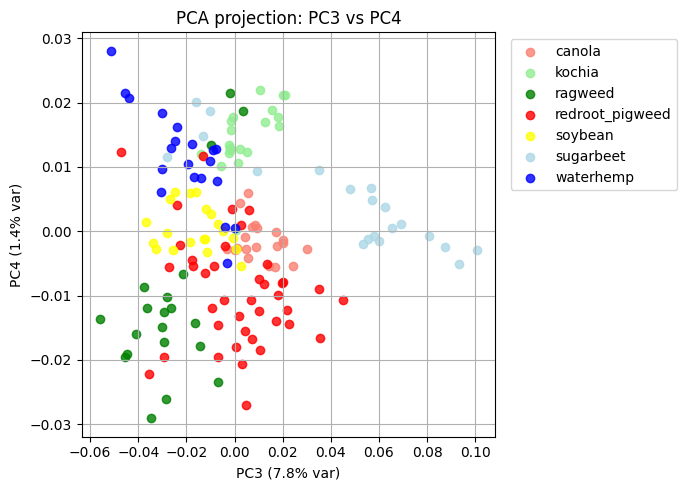

In [102]:
fig, ax = plt.subplots(figsize=(7, 5))

for cls in labels.unique():
    subset = spectra_pca_df[spectra_pca_df["class"] == cls]
    ax.scatter(
        subset["PC3"],
        subset["PC4"],
        label=cls,
        color=color_dict[cls],
        alpha=0.8
    )

ax.set_xlabel(f"PC3 ({explained_var[2]:.1f}% var)")
ax.set_ylabel(f"PC4 ({explained_var[3]:.1f}% var)")
ax.set_title("PCA projection: PC3 vs PC4")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True)

plt.tight_layout()
plt.show()

## 14. PCA loadings

The loadings indicate which wavelengths contribute the most to each principal component.

In [103]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=preprocessed_spectra.columns.astype(float),
    columns=["PC1", "PC2", "PC3", "PC4"]
)

display(loadings.head())

,PC1,PC2,PC3,PC4
397.66,0.010402,0.439100,0.192107,0.190375
400.28,0.007297,0.381213,0.164470,0.171063
402.90,0.004295,0.328750,0.138934,0.150767
405.52,0.001397,0.281712,0.115499,0.129486
408.13,-0.001397,0.240100,0.094166,0.107220


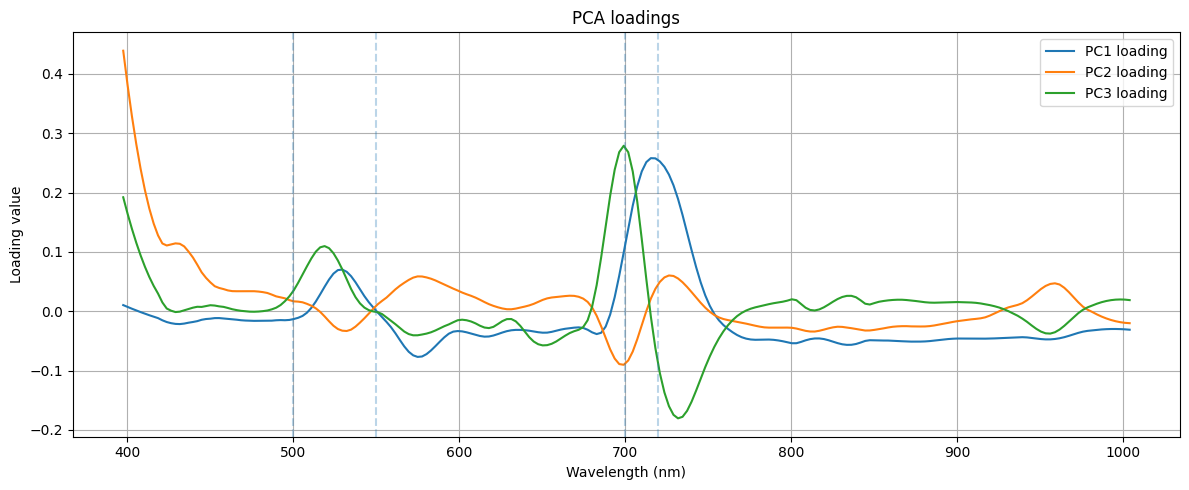

In [104]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(loadings.index, loadings["PC1"], label="PC1 loading")
ax.plot(loadings.index, loadings["PC2"], label="PC2 loading")
ax.plot(loadings.index, loadings["PC3"], label="PC3 loading")

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Loading value")
ax.set_title("PCA loadings")
ax.legend()
ax.grid(True)
for wl in [500, 550, 700, 720]:
    plt.axvline(wl, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

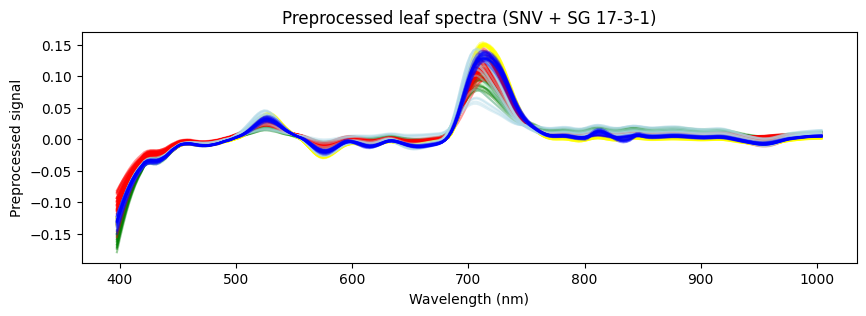

In [106]:
fig, ax = plt.subplots(figsize=(10, 3))

wavelengths = preprocessed_spectra.columns.astype(float)

for i, (_, row) in enumerate(preprocessed_spectra.iterrows()):
    ax.plot(
        wavelengths,
        row.values,
        color=color_dict[labels.iloc[i]],
        alpha=0.4
    )

ax.set_xlabel("Wavelength (nm)") 
ax.set_ylabel("Preprocessed signal") 
ax.set_title("Preprocessed leaf spectra (SNV + SG 17-3-1)")

plt.show()